## Experiment 2: Classification With and Without Meta-Characteristics

This experiment evaluates how ID/OOD classification quality changes when we include or exclude meta-characteristics in the final representation.

Compared setups:
- meta-only representation
- meta + raw features representation
- raw-only representation


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from partition_ood import (
    load_dataset,
    cross_validate_ood_classifiers,
    DEFAULT_META_FEATURES,
)

sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
TEST_SIZE = 0.3
CV_FOLDS = 5
BALANCE_STRATEGY = 'oversample'
INCLUDE_MLP = True
PARTITION_PARAMS = {
    'n_bins': 10,
    'n_kmeans_clusters': 10,
    'n_tree_partitions': 5,
    'tree_max_depth': 3,
    'partition_fit_data': 'id',
}
SIGNIFICANT_META_FEATURES = [
    'dist_to_mean', 'normalized_dist', 'cosine_dist', 'dist_to_median', 'log_likelihood',
    'local_outlier_factor_score', 'knn_distance_k',
    'mean_norm', 'std_norm', 'skew_norm', 'kurtosis_norm', 'median_abs_deviation_norm',
    'iqr_norm', 'trimmed_mean_norm',
    'cell_entropy', 'marginal_entropy_mean', 'marginal_entropy_std',
    'marginal_kl_to_reference_mean', 'quantile_surprisal_mean',
    'mahalanobis', 'covariance_trace', 'covariance_logdet', 'mean_abs_correlation',
    'pairwise_pearson_corr_mean_abs', 'pairwise_spearman_corr_mean_abs',
    'covariance_condition_number',
    'pairwise_mutual_info_mean', 'pairwise_mutual_info_max', 'total_correlation',
    'joint_entropy_pairwise_mean', 'pairwise_js_divergence_mean',
    'log_count', 'density', 'out_of_range_count', 'n_beyond_2std',
    'partition_agreement_count', 'leaf_depth',
]

REPRESENTATION_CONFIGS = [
    {
        'config': 'meta_only',
        'use_raw_features': False,
        'meta_features': SIGNIFICANT_META_FEATURES,
        'label': 'Meta only',
    },
    {
        'config': 'meta_plus_raw',
        'use_raw_features': True,
        'meta_features': SIGNIFICANT_META_FEATURES,
        'label': 'Meta + raw',
    },
    {
        'config': 'raw_only',
        'use_raw_features': True,
        'meta_features': [],
        'label': 'Raw only',
    },
]


def evaluate_representation(ID_data, OOD_data, cfg, dataset_name):
    fold_metrics, summary_df, _ = cross_validate_ood_classifiers(
        ID_data=ID_data,
        OOD_data=OOD_data,
        n_splits=CV_FOLDS,
        random_state=RANDOM_STATE,
        use_raw_features=cfg['use_raw_features'],
        meta_features=cfg['meta_features'],
        n_bins=PARTITION_PARAMS['n_bins'],
        n_kmeans_clusters=PARTITION_PARAMS['n_kmeans_clusters'],
        n_tree_partitions=PARTITION_PARAMS['n_tree_partitions'],
        tree_max_depth=PARTITION_PARAMS['tree_max_depth'],
        partition_fit_data=PARTITION_PARAMS['partition_fit_data'],
        balance_strategy=BALANCE_STRATEGY,
        include_mlp=INCLUDE_MLP,
    )

    df = summary_df.copy()
    df = df.rename(columns={
        'model': 'classifier',
        'roc_auc_mean': 'roc-auc',
        'pr_auc_mean': 'pr-auc',
        'accuracy_mean': 'accuracy',
        'precision_mean': 'precision',
        'recall_mean': 'recall',
        'f1_mean': 'f1-score',
    })
    df['config'] = cfg['config']
    df['config_label'] = cfg['label']
    df['n_meta_features'] = len(cfg['meta_features'])

    fold_df = fold_metrics.copy()
    fold_df['config'] = cfg['config']
    fold_df['config_label'] = cfg['label']

    return df, fold_df


def run_experiment_for_dataset(dataset_name):
    ID_data, OOD_data = load_dataset(dataset_name)
    summary_parts = []
    fold_parts = []
    for cfg in REPRESENTATION_CONFIGS:
        summary_df, fold_df = evaluate_representation(ID_data, OOD_data, cfg, dataset_name)
        summary_parts.append(summary_df)
        fold_parts.append(fold_df)
    return pd.concat(summary_parts, ignore_index=True), pd.concat(fold_parts, ignore_index=True)


def plot_results(dataset_name, results_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=results_df, x='classifier', y='roc-auc', hue='config_label', ax=axes[0])
    axes[0].set_title(f'{dataset_name}: CV ROC-AUC')
    axes[0].set_xlabel('Classifier')
    axes[0].set_ylabel('ROC-AUC')
    axes[0].tick_params(axis='x', rotation=10)
    axes[0].legend(title='Representation')

    sns.barplot(data=results_df, x='classifier', y='f1-score', hue='config_label', ax=axes[1])
    axes[1].set_title(f'{dataset_name}: CV F1-score')
    axes[1].set_xlabel('Classifier')
    axes[1].set_ylabel('F1-score')
    axes[1].tick_params(axis='x', rotation=10)
    axes[1].legend(title='Representation')

    plt.tight_layout()
    plt.show()


def show_dataset_results(dataset_name):
    results_df, fold_df = run_experiment_for_dataset(dataset_name)
    display(results_df.sort_values(['classifier', 'config_label']))
    summary = (
        results_df
        .groupby('config_label', as_index=False)[['roc-auc', 'pr-auc', 'accuracy', 'precision', 'recall', 'f1-score']]
        .mean()
        .sort_values('roc-auc', ascending=False)
    )
    display(summary)
    plot_results(dataset_name, results_df)
    return results_df, summary


## Taxi Data

,classifier,roc-auc,roc_auc_std,pr-auc,pr_auc_std,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1-score,f1_std,config,config_label,n_meta_features
3,Logistic Regression,0.99798,0.001333,0.99694,0.002021,0.99184,0.002890,0.98842,0.005118,0.9954,0.001817,0.99188,0.002852,meta_plus_raw,Meta + raw,37
0,Logistic Regression,0.99806,0.001284,0.99696,0.002012,0.99216,0.003342,0.98900,0.005837,0.9954,0.001851,0.99218,0.003316,meta_only,Meta only,37
6,Logistic Regression,0.49432,0.007679,0.50626,0.009368,0.49562,0.010055,0.49574,0.009764,0.5098,0.017835,0.50256,0.012165,raw_only,Raw only,0
4,MLP,0.99766,0.000727,0.99640,0.001654,0.98306,0.004959,0.97778,0.007989,0.9886,0.003489,0.98316,0.004859,meta_plus_raw,Meta + raw,37
1,MLP,0.99732,0.001352,0.99628,0.001788,0.98328,0.006779,0.97850,0.011379,0.9883,0.002139,0.98338,0.006676,meta_only,Meta only,37
7,MLP,0.91548,0.036312,0.92496,0.031946,0.83364,0.040718,0.84450,0.032055,0.8169,0.057231,0.83024,0.044422,raw_only,Raw only,0
5,Random Forest,0.99728,0.000832,0.99694,0.001184,0.98458,0.004033,0.98754,0.003807,0.9816,0.005067,0.98454,0.004086,meta_plus_raw,Meta + raw,37
2,Random Forest,0.99590,0.000990,0.99552,0.001324,0.97784,0.003866,0.98156,0.003450,0.9740,0.005590,0.97778,0.003869,meta_only,Meta only,37
8,Random Forest,0.99994,0.000055,0.99994,0.000055,0.99696,0.001361,0.99480,0.001525,0.9991,0.001475,0.99698,0.001366,raw_only,Raw only,0


,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
0,Meta + raw,0.997640,0.996760,0.986493,0.984580,0.988533,0.986527
1,Meta only,0.997093,0.996253,0.984427,0.983020,0.985900,0.984447
2,Raw only,0.803247,0.810387,0.775407,0.778347,0.775267,0.776593


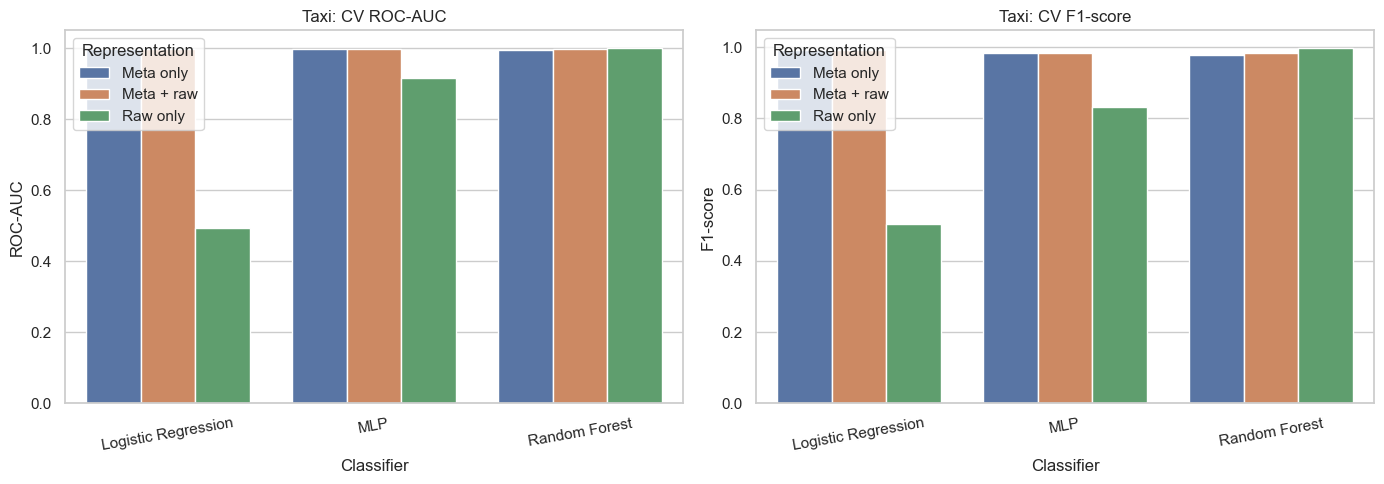

,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
0,Meta + raw,0.997640,0.996760,0.986493,0.984580,0.988533,0.986527
1,Meta only,0.997093,0.996253,0.984427,0.983020,0.985900,0.984447
2,Raw only,0.803247,0.810387,0.775407,0.778347,0.775267,0.776593


In [2]:
results_taxi, summary_taxi = show_dataset_results('Taxi')
summary_taxi

## Electricity Data

,classifier,roc-auc,roc_auc_std,pr-auc,pr_auc_std,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1-score,f1_std,config,config_label,n_meta_features
3,Logistic Regression,0.97106,0.001698,0.96356,0.001448,0.91266,0.003248,0.88328,0.004315,0.95130,0.002197,0.91602,0.002972,meta_plus_raw,Meta + raw,37
0,Logistic Regression,0.97004,0.001920,0.96216,0.001557,0.91040,0.003274,0.88020,0.004446,0.95050,0.004967,0.91396,0.003139,meta_only,Meta only,37
6,Logistic Regression,0.80308,0.008789,0.76914,0.011353,0.72920,0.012014,0.71872,0.016920,0.75534,0.018146,0.73638,0.010423,raw_only,Raw only,0
4,MLP,0.97096,0.000838,0.96296,0.002583,0.91606,0.002338,0.89620,0.011114,0.94170,0.015642,0.91824,0.002834,meta_plus_raw,Meta + raw,37
1,MLP,0.97048,0.002260,0.96266,0.004314,0.91518,0.003434,0.89124,0.008513,0.94630,0.012682,0.91782,0.003623,meta_only,Meta only,37
7,MLP,0.97764,0.001071,0.97402,0.001303,0.92248,0.003845,0.91148,0.008266,0.93630,0.012911,0.92364,0.004182,raw_only,Raw only,0
5,Random Forest,0.97764,0.001736,0.97350,0.002652,0.91896,0.003328,0.88472,0.004491,0.96372,0.004496,0.92252,0.003111,meta_plus_raw,Meta + raw,37
2,Random Forest,0.97644,0.001442,0.97112,0.002367,0.91770,0.003270,0.88428,0.004445,0.96148,0.004677,0.92126,0.003115,meta_only,Meta only,37
8,Random Forest,0.98398,0.001190,0.98128,0.001798,0.93370,0.003137,0.90698,0.003983,0.96672,0.002649,0.93594,0.002944,raw_only,Raw only,0


,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
0,Meta + raw,0.973220,0.966673,0.915893,0.888067,0.95224,0.918927
1,Meta only,0.972320,0.965313,0.914427,0.885240,0.95276,0.917680
2,Raw only,0.921567,0.908147,0.861793,0.845727,0.88612,0.865320


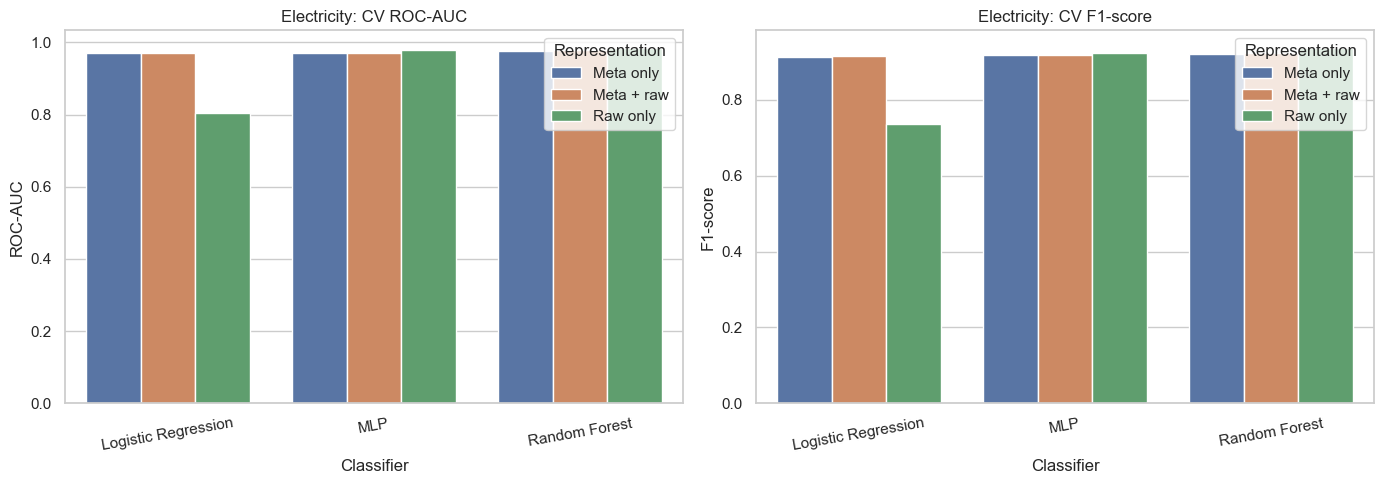

,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
0,Meta + raw,0.973220,0.966673,0.915893,0.888067,0.95224,0.918927
1,Meta only,0.972320,0.965313,0.914427,0.885240,0.95276,0.917680
2,Raw only,0.921567,0.908147,0.861793,0.845727,0.88612,0.865320


In [3]:
results_electricity, summary_electricity = show_dataset_results('Electricity')
summary_electricity

## Income Data

,classifier,roc-auc,roc_auc_std,pr-auc,pr_auc_std,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1-score,f1_std,config,config_label,n_meta_features
3,Logistic Regression,0.91948,0.000597,0.82606,0.003157,0.82088,0.001883,0.66146,0.002029,0.91690,0.004948,0.76852,0.002683,meta_plus_raw,Meta + raw,37
0,Logistic Regression,0.91736,0.001268,0.82280,0.004167,0.81828,0.000965,0.65808,0.001028,0.91512,0.004892,0.76562,0.001708,meta_only,Meta only,37
6,Logistic Regression,0.87030,0.003343,0.76086,0.005721,0.76820,0.003706,0.63212,0.004230,0.68248,0.011424,0.65630,0.007209,raw_only,Raw only,0
4,MLP,0.90286,0.002219,0.79558,0.008167,0.81510,0.003667,0.68142,0.008353,0.80770,0.013289,0.73912,0.004395,meta_plus_raw,Meta + raw,37
1,MLP,0.90252,0.002450,0.79384,0.007841,0.81504,0.001518,0.68060,0.007288,0.81046,0.018504,0.73970,0.004006,meta_only,Meta only,37
7,MLP,0.90346,0.002809,0.78900,0.011594,0.81334,0.005025,0.68052,0.021006,0.80504,0.052326,0.73622,0.012974,raw_only,Raw only,0
5,Random Forest,0.91412,0.002338,0.80306,0.007895,0.82792,0.002526,0.68842,0.002822,0.85760,0.007573,0.76374,0.004078,meta_plus_raw,Meta + raw,37
2,Random Forest,0.91312,0.002364,0.80100,0.008770,0.82614,0.000882,0.68548,0.001766,0.85730,0.007530,0.76180,0.002327,meta_only,Meta only,37
8,Random Forest,0.91440,0.002391,0.79750,0.006674,0.83118,0.004289,0.70120,0.006487,0.83552,0.007946,0.76246,0.005893,raw_only,Raw only,0


,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
0,Meta + raw,0.912153,0.808233,0.82130,0.67710,0.860733,0.757127
1,Meta only,0.911000,0.805880,0.81982,0.67472,0.860960,0.755707
2,Raw only,0.896053,0.782453,0.80424,0.67128,0.774347,0.718327


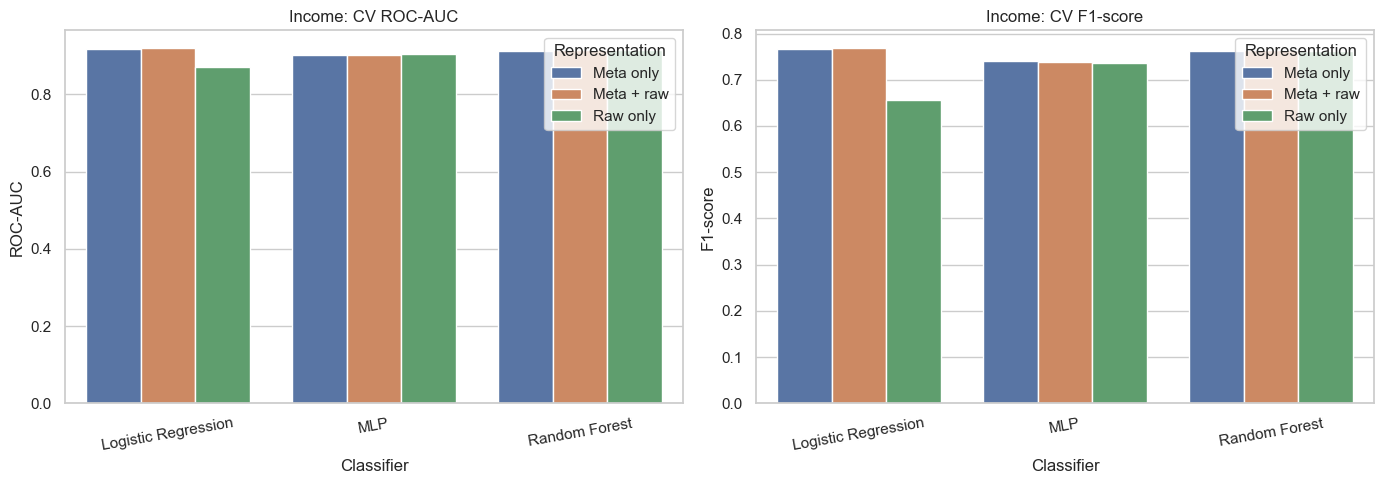

,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
0,Meta + raw,0.912153,0.808233,0.82130,0.67710,0.860733,0.757127
1,Meta only,0.911000,0.805880,0.81982,0.67472,0.860960,0.755707
2,Raw only,0.896053,0.782453,0.80424,0.67128,0.774347,0.718327


In [4]:
results_income, summary_income = show_dataset_results('Income')
summary_income

## MVx6 Data

In [ ]:
results_mvx6, summary_mvx6 = show_dataset_results('MVx6')
summary_mvx6

## Diabetes Data

,classifier,roc-auc,pr-auc,accuracy,precision,recall,f1-score,config,config_label,n_meta_features
2,Logistic Regression,0.9268,0.3456,0.9556,0.4378,0.2111,0.2849,meta_plus_raw,Meta + raw,10
0,Logistic Regression,0.9277,0.3447,0.9546,0.4140,0.1978,0.2677,meta_only,Meta only,10
4,Logistic Regression,0.9053,0.3350,0.9559,0.3462,0.0600,0.1023,raw_only,Raw only,0
3,Random Forest,0.9344,0.3775,0.9575,0.3846,0.0222,0.0420,meta_plus_raw,Meta + raw,10
1,Random Forest,0.9344,0.3806,0.9584,0.5455,0.0400,0.0745,meta_only,Meta only,10
5,Random Forest,0.9479,0.4512,0.9587,0.7333,0.0244,0.0473,raw_only,Raw only,0


,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
1,Meta only,0.93105,0.36265,0.95650,0.47975,0.11890,0.17110
0,Meta + raw,0.93060,0.36155,0.95655,0.41120,0.11665,0.16345
2,Raw only,0.92660,0.39310,0.95730,0.53975,0.04220,0.07480


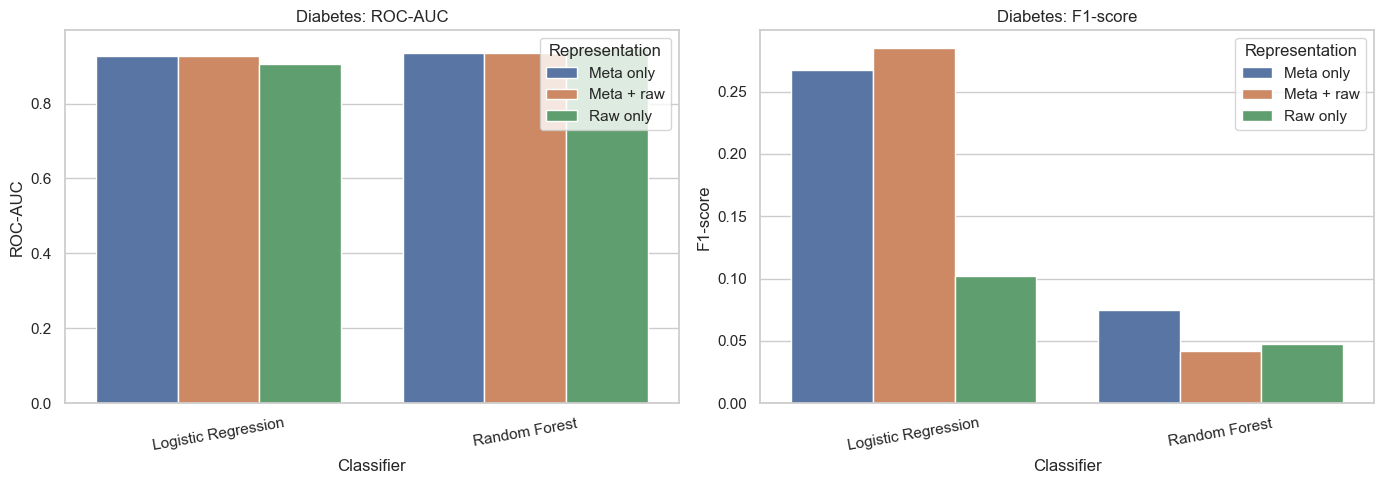

,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
1,Meta only,0.93105,0.36265,0.95650,0.47975,0.11890,0.17110
0,Meta + raw,0.93060,0.36155,0.95655,0.41120,0.11665,0.16345
2,Raw only,0.92660,0.39310,0.95730,0.53975,0.04220,0.07480


In [ ]:
results_diabetes, summary_diabetes = show_dataset_results('Diabetes')
summary_diabetes

## California Data

,classifier,roc-auc,pr-auc,accuracy,precision,recall,f1-score,config,config_label,n_meta_features
2,Logistic Regression,0.9938,0.9932,0.9583,0.9560,0.9609,0.9584,meta_plus_raw,Meta + raw,10
0,Logistic Regression,0.9930,0.9925,0.9562,0.9511,0.9619,0.9565,meta_only,Meta only,10
4,Logistic Regression,0.9930,0.9930,0.9498,0.9275,0.9758,0.9510,raw_only,Raw only,0
3,Random Forest,0.9961,0.9961,0.9658,0.9652,0.9664,0.9658,meta_plus_raw,Meta + raw,10
1,Random Forest,0.9949,0.9945,0.9609,0.9580,0.9641,0.9610,meta_only,Meta only,10
5,Random Forest,0.9971,0.9972,0.9732,0.9744,0.9719,0.9732,raw_only,Raw only,0


,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
2,Raw only,0.99505,0.99510,0.96150,0.95095,0.97385,0.96210
0,Meta + raw,0.99495,0.99465,0.96205,0.96060,0.96365,0.96210
1,Meta only,0.99395,0.99350,0.95855,0.95455,0.96300,0.95875


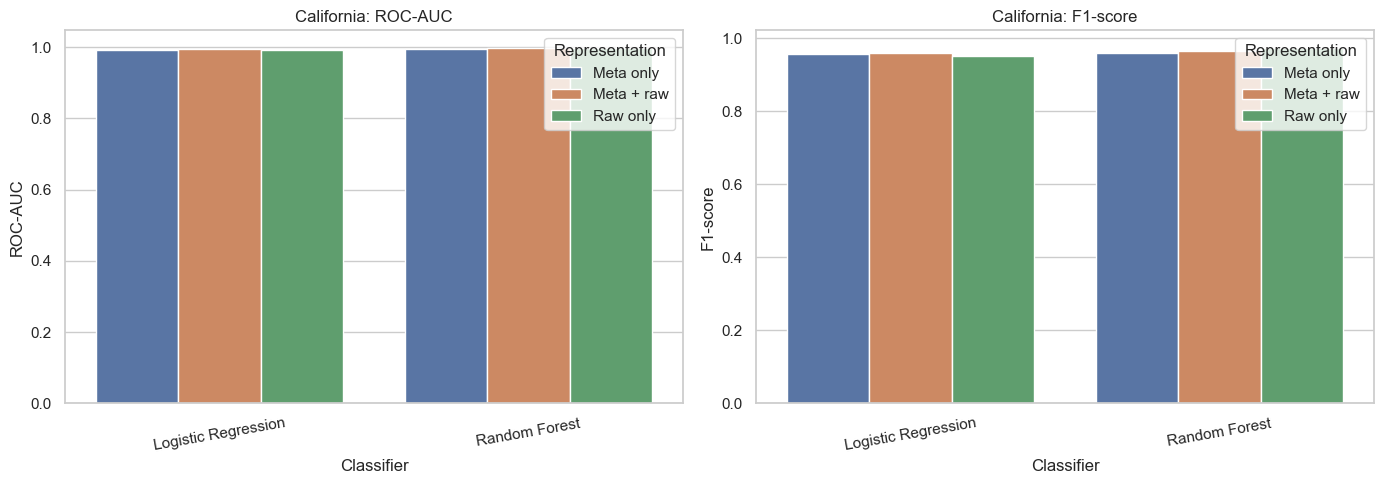

,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
2,Raw only,0.99505,0.99510,0.96150,0.95095,0.97385,0.96210
0,Meta + raw,0.99495,0.99465,0.96205,0.96060,0.96365,0.96210
1,Meta only,0.99395,0.99350,0.95855,0.95455,0.96300,0.95875


In [ ]:
results_california, summary_california = show_dataset_results('California')
summary_california

## ACS Accidents Data

,classifier,roc-auc,pr-auc,accuracy,precision,recall,f1-score,config,config_label,n_meta_features
2,Logistic Regression,0.9998,0.9984,0.9970,0.9932,0.9865,0.9899,meta_plus_raw,Meta + raw,10
0,Logistic Regression,0.9773,0.9164,0.9533,0.8959,0.7759,0.8316,meta_only,Meta only,10
4,Logistic Regression,0.4510,0.1405,0.8513,0.0000,0.0000,0.0000,raw_only,Raw only,0
3,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,meta_plus_raw,Meta + raw,10
1,Random Forest,0.9792,0.9139,0.9410,0.9453,0.6403,0.7634,meta_only,Meta only,10
5,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,raw_only,Raw only,0


,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
0,Meta + raw,0.99990,0.99920,0.99850,0.9966,0.99325,0.99495
1,Meta only,0.97825,0.91515,0.94715,0.9206,0.70810,0.79750
2,Raw only,0.72550,0.57025,0.92565,0.5000,0.50000,0.50000


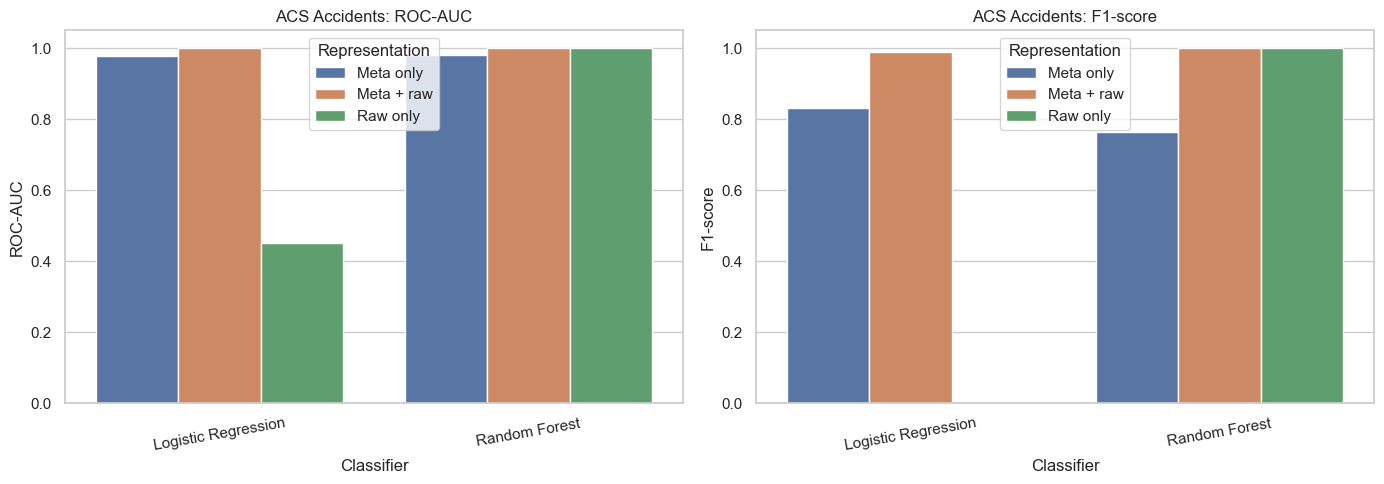

,config_label,roc-auc,pr-auc,accuracy,precision,recall,f1-score
0,Meta + raw,0.99990,0.99920,0.99850,0.9966,0.99325,0.99495
1,Meta only,0.97825,0.91515,0.94715,0.9206,0.70810,0.79750
2,Raw only,0.72550,0.57025,0.92565,0.5000,0.50000,0.50000


In [ ]:
results_acs, summary_acs = show_dataset_results('ACS Accidents')
summary_acs